In [ ]:
!pip install -q ultralytics openpyxl Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.9 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import os, yaml, glob, shutil, cv2
import numpy as np
from PIL import Image
from openpyxl import Workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from io import BytesIO

# Upload kaggle.json
files.upload()
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Download & unzip dataset
!kaggle datasets download -d anushkagovindkadam/smart-helmet-detection-using-dl
!unzip -q smart-helmet-detection-using-dl.zip -d helmet_dataset
!rm smart-helmet-detection-using-dl.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/anushkagovindkadam/smart-helmet-detection-using-dl
License(s): MIT
100% 11.0M/11.0M [00:02<00:00, 5.49MB/s]



# New Section

In [ ]:
old_val = '/content/helmet_dataset/data/vaid'
new_val = '/content/helmet_dataset/data/valid'
if os.path.exists(old_val) and not os.path.exists(new_val):
    os.rename(old_val, new_val)
    print("✅ Renamed 'vaid' → 'valid'")

DATA_ROOT = '/content/helmet_dataset/data'

# Verify folders exist
for folder in ['train/images', 'valid/images', 'test/images']:
    path = os.path.join(DATA_ROOT, folder)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    status = "✅" if count > 0 else "❌"
    print(f"{status} {path} — {count} files")

✅ Renamed 'vaid' → 'valid'
✅ /content/helmet_dataset/data/train/images — 368 files
✅ /content/helmet_dataset/data/valid/images — 65 files
✅ /content/helmet_dataset/data/test/images — 52 files


In [ ]:
config = {
    'path': DATA_ROOT,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 2,
    'names': ['helmet', 'no-helmet']
}
YAML_PATH = '/content/helmet_data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)
print(f"✅ YAML saved to {YAML_PATH}")

✅ YAML saved to /content/helmet_data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=YAML_PATH,
    epochs=50,
    imgsz=640,
    device=0,               # Tesla T4 GPU
    name="helmet_project",  # Fixed folder name — no more train2/train3
    exist_ok=True           # Safe to re-run without duplicating folders
)
MODEL_PATH = "/content/runs/detect/helmet_project/weights/best.pt"
print(f"\n✅ Training complete. Model saved to: {MODEL_PATH}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

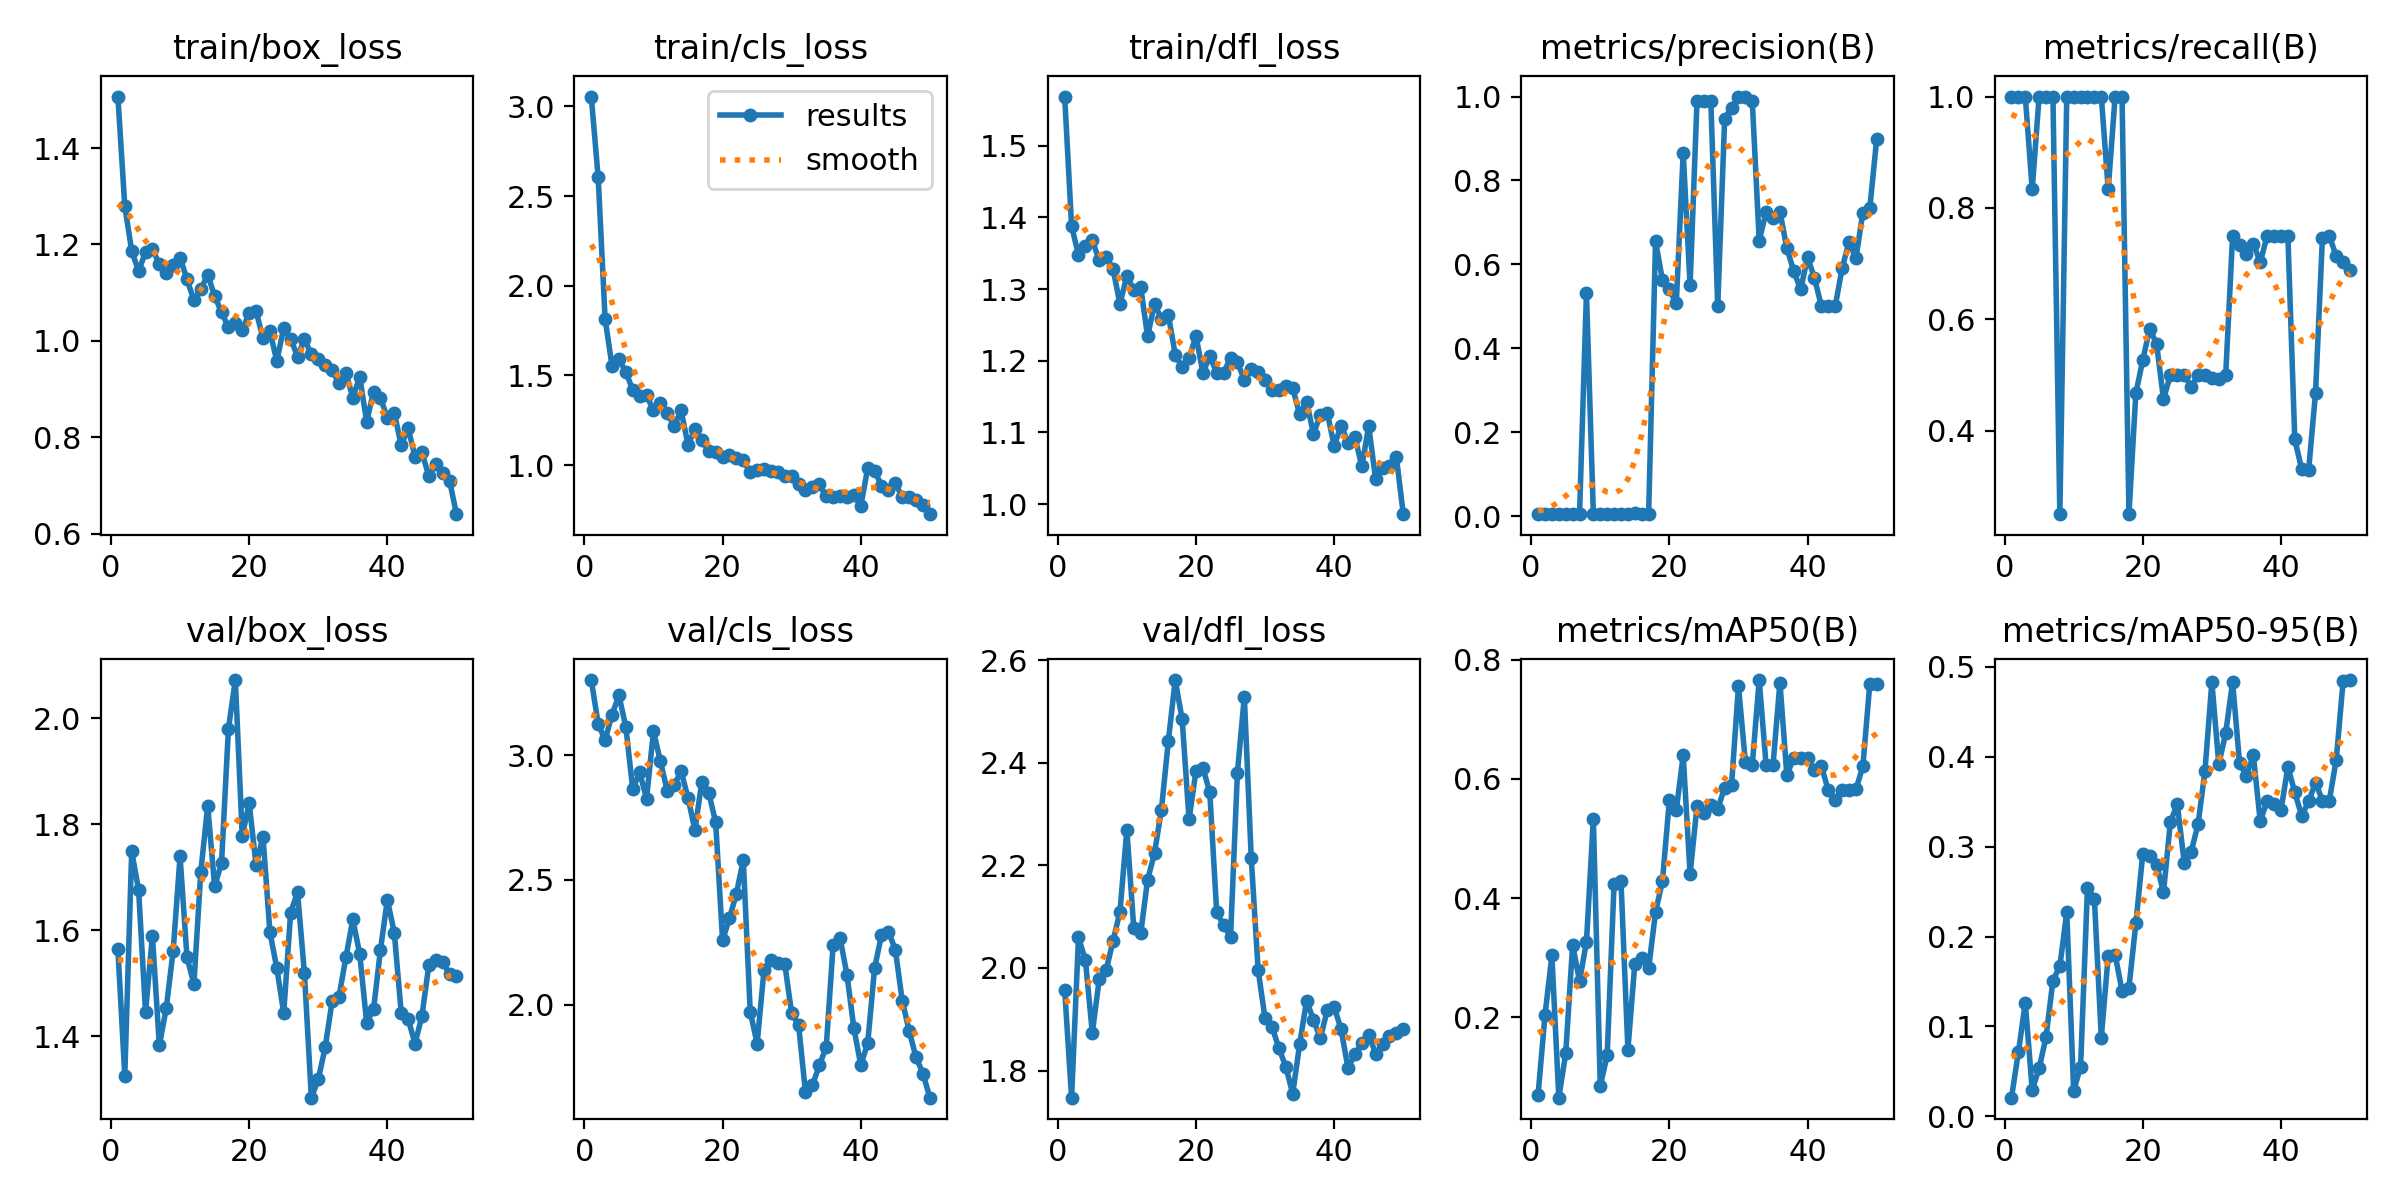

In [ ]:
from IPython.display import Image as IPImage, display

results_img = "/content/runs/detect/helmet_project/results.png"
if os.path.exists(results_img):
    display(IPImage(filename=results_img))
else:
    print("⚠️ results.png not found — training may still be running.")

In [ ]:
model = YOLO(MODEL_PATH)
model.export(format="onnx")
print("✅ ONNX export complete.")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/helmet_project/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 206ms
Prepared 4 packages in 7.64s
Installed 4 packages in 460ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 9.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DEST = "/content/drive/MyDrive/TAMUK_Helmet_Detection/"
os.makedirs(DRIVE_DEST, exist_ok=True)
shutil.copy(MODEL_PATH, os.path.join(DRIVE_DEST, "best.pt"))
shutil.copy(MODEL_PATH.replace(".pt", ".onnx"), os.path.join(DRIVE_DEST, "best.onnx"))
print(f"✅ Backed up to Google Drive: {DRIVE_DEST}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Backed up to Google Drive: /content/drive/MyDrive/TAMUK_Helmet_Detection/


In [ ]:
VIDEO_PATH = "traffic_test.mp4"   # ← change if your file has a different name

if not os.path.exists(VIDEO_PATH):
    print(f"❌ Upload '{VIDEO_PATH}' to /content/ first.")
else:
    model = YOLO(MODEL_PATH)
    print(f"🎬 Processing {VIDEO_PATH} ...")
    # stream=True avoids RAM overload on long videos
    pred_results = list(model.predict(
        source=VIDEO_PATH,
        conf=0.3,
        save=True,
        save_txt=False,
        stream=True
    ))
    out_folder = max(glob.glob("runs/detect/predict*"), key=os.path.getmtime)
    print(f"✅ Video saved to: {out_folder}")

❌ Upload 'traffic_test.mp4' to /content/ first.


In [ ]:
OUTPUT_DIR   = "/content/helmet_frame_analysis"
FRAMES_DIR   = os.path.join(OUTPUT_DIR, "frames")
THUMBS_DIR   = os.path.join(OUTPUT_DIR, "thumbnails")
EXCEL_PATH   = os.path.join(OUTPUT_DIR, "helmet_frame_analysis.xlsx")
THUMB_W, THUMB_H = 160, 90   # thumbnail size embedded in Excel

os.makedirs(FRAMES_DIR, exist_ok=True)
os.makedirs(THUMBS_DIR, exist_ok=True)

model = YOLO(MODEL_PATH)

# --- collect detection data ---
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30
cap.release()

frame_data = []   # list of dicts — one per frame

print("🔍 Running per-frame inference …")
for result in model.predict(source=VIDEO_PATH, conf=0.3, stream=True, verbose=False):
    frame_idx = result.path  # frame index stored here by Ultralytics

    # Annotated frame image (numpy BGR)
    annotated = result.plot()

    # Frame number from the result's speed / orig_shape context
    # Ultralytics doesn't expose frame_idx directly in stream mode,
    # so we count manually
    fn = len(frame_data) + 1
    timestamp = round(fn / fps, 2)

    # Save full-resolution annotated frame
    frame_file = os.path.join(FRAMES_DIR, f"frame_{fn:04d}.jpg")
    cv2.imwrite(frame_file, annotated)

    # Save small thumbnail
    thumb = cv2.resize(annotated, (THUMB_W, THUMB_H))
    thumb_file = os.path.join(THUMBS_DIR, f"thumb_{fn:04d}.jpg")
    cv2.imwrite(thumb_file, thumb)

    # Count detections per class
    helmet_count    = 0
    no_helmet_count = 0
    max_conf        = 0.0
    conf_list       = []

    if result.boxes is not None and len(result.boxes):
        for box in result.boxes:
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            conf_list.append(round(conf, 3))
            if cls == 0:
                helmet_count += 1
            else:
                no_helmet_count += 1
        max_conf = round(max(conf_list), 3)

    # Determine detection status for this frame
    if helmet_count > 0 and no_helmet_count > 0:
        status = "Both 🔶"
    elif helmet_count > 0:
        status = "Helmet ✅"
    elif no_helmet_count > 0:
        status = "No Helmet ❌"
    else:
        status = "None —"

    frame_data.append({
        "frame":          fn,
        "timestamp_s":    timestamp,
        "helmet":         helmet_count,
        "no_helmet":      no_helmet_count,
        "total":          helmet_count + no_helmet_count,
        "status":         status,
        "max_conf":       max_conf,
        "conf_list":      ", ".join(map(str, conf_list)),
        "thumb_path":     thumb_file,
    })

print(f"✅ Processed {len(frame_data)} frames.")

# --- build Excel workbook ---
print("📊 Building Excel report …")

wb = Workbook()

# ── Summary Sheet ──────────────────────────────────────────
ws_sum = wb.active
ws_sum.title = "Summary"

HEADER_FILL  = PatternFill("solid", start_color="1F4E79")
ALT_FILL     = PatternFill("solid", start_color="D6E4F0")
HELMET_FILL  = PatternFill("solid", start_color="C6EFCE")   # green
NOHELM_FILL  = PatternFill("solid", start_color="FFC7CE")   # red
BOTH_FILL    = PatternFill("solid", start_color="FFEB9C")   # orange
NONE_FILL    = PatternFill("solid", start_color="F2F2F2")   # grey
WHITE_FILL   = PatternFill("solid", start_color="FFFFFF")

STATUS_FILL = {
    "Helmet ✅":    HELMET_FILL,
    "No Helmet ❌": NOHELM_FILL,
    "Both 🔶":      BOTH_FILL,
    "None —":       NONE_FILL,
}
BORDER       = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin')
)

def hdr_cell(ws, row, col, value, width=None):
    c = ws.cell(row=row, column=col, value=value)
    c.font      = Font(name="Arial", bold=True, color="FFFFFF", size=11)
    c.fill      = HEADER_FILL
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border    = BORDER
    if width:
        ws.column_dimensions[get_column_letter(col)].width = width

# Title
ws_sum.merge_cells("A1:H1")
title_cell = ws_sum["A1"]
title_cell.value     = "Helmet Detection — Frame Analysis Report"
title_cell.font      = Font(name="Arial", bold=True, size=14, color="FFFFFF")
title_cell.fill      = PatternFill("solid", start_color="10375C")
title_cell.alignment = Alignment(horizontal="center", vertical="center")
ws_sum.row_dimensions[1].height = 30

# Sub-title info
ws_sum["A2"] = f"Video: {VIDEO_PATH}   |   Total frames: {len(frame_data)}   |   FPS: {fps}"
ws_sum["A2"].font = Font(name="Arial", italic=True, size=10, color="595959")
ws_sum.merge_cells("A2:H2")

# Legend row
legend = [
    ("Helmet ✅", "C6EFCE"), ("No Helmet ❌", "FFC7CE"),
    ("Both 🔶", "FFEB9C"), ("None —", "F2F2F2"),
]
ws_sum.merge_cells("A3:B3")
ws_sum["A3"].value     = "Legend:"
ws_sum["A3"].font      = Font(name="Arial", bold=True, size=10)
ws_sum["A3"].alignment = Alignment(horizontal="right", vertical="center")
for li, (label, color) in enumerate(legend, start=3):
    c = ws_sum.cell(row=3, column=li, value=label)
    c.fill      = PatternFill("solid", start_color=color)
    c.font      = Font(name="Arial", size=10, bold=True)
    c.alignment = Alignment(horizontal="center", vertical="center")
    c.border    = BORDER
ws_sum.row_dimensions[3].height = 18

# Column headers (row 4)
headers = ["Frame #", "Timestamp (s)", "Detection Status", "Helmets ✅", "No-Helmets ❌", "Total Detected", "Max Confidence", "All Confidences"]
widths  = [10, 15, 18, 13, 15, 16, 16, 30]
for col, (h, w) in enumerate(zip(headers, widths), start=1):
    hdr_cell(ws_sum, 4, col, h, w)
ws_sum.row_dimensions[4].height = 25

# Data rows
for i, d in enumerate(frame_data):
    r    = i + 5
    row_fill = ALT_FILL if i % 2 == 0 else WHITE_FILL
    status_fill = STATUS_FILL.get(d["status"], row_fill)

    values = [
        d["frame"], d["timestamp_s"], d["status"],
        d["helmet"], d["no_helmet"], d["total"],
        d["max_conf"], d["conf_list"]
    ]
    for col, val in enumerate(values, start=1):
        c = ws_sum.cell(row=r, column=col, value=val)
        c.font      = Font(name="Arial", size=10,
                           bold=(col == 3))  # bold the status column
        c.alignment = Alignment(horizontal="center", vertical="center")
        c.border    = BORDER
        # Status column gets its own colour; rest alternates
        c.fill = status_fill if col == 3 else row_fill

# Freeze header rows
ws_sum.freeze_panes = "A5"

# ── Frame Thumbnails Sheet ──────────────────────────────────
ws_img = wb.create_sheet("Frame Thumbnails")

img_headers = ["Frame #", "Timestamp (s)", "Detection Status", "Helmets ✅", "No-Helmets ❌", "Snapshot"]
img_widths  = [10, 15, 18, 13, 15, 24]
for col, (h, w) in enumerate(zip(img_headers, img_widths), start=1):
    hdr_cell(ws_img, 1, col, h, w)
ws_img.row_dimensions[1].height = 25

ROW_HEIGHT_PX = 70

for i, d in enumerate(frame_data):
    r    = i + 2
    row_fill    = ALT_FILL if i % 2 == 0 else WHITE_FILL
    status_fill = STATUS_FILL.get(d["status"], row_fill)

    row_values = [d["frame"], d["timestamp_s"], d["status"], d["helmet"], d["no_helmet"]]
    for col, val in enumerate(row_values, start=1):
        c = ws_img.cell(row=r, column=col, value=val)
        c.font      = Font(name="Arial", size=10, bold=(col == 3))
        c.alignment = Alignment(horizontal="center", vertical="center")
        c.border    = BORDER
        c.fill      = status_fill if col == 3 else row_fill

    # Embed thumbnail in column F
    if os.path.exists(d["thumb_path"]):
        img_obj        = XLImage(d["thumb_path"])
        img_obj.width  = THUMB_W * 0.75
        img_obj.height = THUMB_H * 0.75
        ws_img.add_image(img_obj, f"F{r}")

    ws_img.row_dimensions[r].height = ROW_HEIGHT_PX

ws_img.freeze_panes = "A2"

# ── Stats Sheet ─────────────────────────────────────────────
ws_stats = wb.create_sheet("Detection Stats")

total_frames   = len(frame_data)
helmet_frames  = sum(1 for d in frame_data if d["status"] == "Helmet ✅")
nohelm_frames  = sum(1 for d in frame_data if d["status"] == "No Helmet ❌")
both_frames    = sum(1 for d in frame_data if d["status"] == "Both 🔶")
none_frames    = sum(1 for d in frame_data if d["status"] == "None —")
total_helmets  = sum(d["helmet"]    for d in frame_data)
total_nohelm   = sum(d["no_helmet"] for d in frame_data)
avg_conf_vals  = [d["max_conf"] for d in frame_data if d["max_conf"] > 0]
avg_conf       = round(sum(avg_conf_vals) / len(avg_conf_vals), 3) if avg_conf_vals else 0

stats = [
    ("Metric", "Value", ""),
    ("── Frame Status Breakdown ──", "", ""),
    ("Frames — Helmet Only ✅",         helmet_frames,  "C6EFCE"),
    ("Frames — No Helmet Only ❌",       nohelm_frames,  "FFC7CE"),
    ("Frames — Both Detected 🔶",        both_frames,    "FFEB9C"),
    ("Frames — No Detection —",          none_frames,    "F2F2F2"),
    ("── Detection Totals ──", "", ""),
    ("Total Helmet Detections",          total_helmets,  ""),
    ("Total No-Helmet Detections",       total_nohelm,   ""),
    ("── Confidence ──", "", ""),
    ("Avg Max Confidence (per frame)",   avg_conf,       ""),
    ("── Summary ──", "", ""),
    ("Total Frames Analysed",            total_frames,   ""),
    ("Detection Rate (%)", f"=B3/{total_frames}*100",    ""),
]

for row_idx, (label, value, color) in enumerate(stats, start=1):
    is_header_row = row_idx == 1
    is_section    = str(label).startswith("──")
    lc = ws_stats.cell(row=row_idx, column=1, value=label)
    vc = ws_stats.cell(row=row_idx, column=2, value=value if not is_section else "")
    for c in (lc, vc):
        if is_header_row:
            c.font  = Font(name="Arial", bold=True, size=11, color="FFFFFF")
            c.fill  = HEADER_FILL
        elif is_section:
            c.font  = Font(name="Arial", bold=True, size=10, color="FFFFFF")
            c.fill  = PatternFill("solid", start_color="2E75B6")
        else:
            bg = color if color else ("D6E4F0" if row_idx % 2 == 0 else "FFFFFF")
            c.font  = Font(name="Arial", size=11)
            c.fill  = PatternFill("solid", start_color=bg)
        c.border    = BORDER
        c.alignment = Alignment(horizontal="center" if is_header_row else "left", vertical="center")

ws_stats.column_dimensions["A"].width = 35
ws_stats.column_dimensions["B"].width = 20

# ── Save ────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f"\n✅ Excel report saved to: {EXCEL_PATH}")
print(f"   Sheets: Summary | Frame Thumbnails | Detection Stats")
print(f"\n   Status breakdown:")
print(f"   🟢 Helmet only   : {helmet_frames} frames")
print(f"   🔴 No helmet only: {nohelm_frames} frames")
print(f"   🟠 Both detected : {both_frames} frames")
print(f"   ⚪ No detection  : {none_frames} frames")

# Download to your computer
files.download(EXCEL_PATH)

🔍 Running per-frame inference …
✅ Processed 192 frames.
📊 Building Excel report …

✅ Excel report saved to: /content/helmet_frame_analysis/helmet_frame_analysis.xlsx
   Sheets: Summary | Frame Thumbnails | Detection Stats

   Status breakdown:
   🟢 Helmet only   : 51 frames
   🔴 No helmet only: 9 frames
   🟠 Both detected : 122 frames
   ⚪ No detection  : 10 frames


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>